## **Introduzione**

La seguente analisi è stata effettuata utilizzando un dataset che raccoglie i dati sui crimini registrati nella città di **Baltimora (Maryland, USA)** tra gli anni 2010 e 2017.
Il dataset contiene informazioni dettagliate su ogni evento criminale, tra cui **data, ora, tipologia di reato, localizzazione geografica, distretto di polizia e coordinate GPS**, coprendo un ampio periodo temporale.

L'obiettivo dell'analisi è quello di effettuare una clusterizzazione dei distretti di polizia basati sui loro profili di criminalità, utilizzando algoritmi di clustering come **K-Means**.

Per l'analisi verranno utilizzate librerie Python come **pandas, matplotlib, seaborn, numpy, scipy e sklearn**, che consentiranno di effettuare una **pulizia accurata dei dati, un'analisi esplorativa (EDA) e la modellazione del modello di clustering**.

**N.B.**: Per questioni di compatibilità con le versioni delle librerie, si consiglia di utilizzare la versione **3.12.4** di Python.

In [2]:
# Installazione dei pacchetti necessari
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import seaborn as sns

### **Import del dataset**

Si inizia l'analisi importando il dataset in formato `.csv`, disponibile al seguente link ufficiale:
🔗 [City of Baltimore Crime Data](https://data.world/data-society/city-of-baltimore-crime-data)

Per avere una visualizzazione piu' dettagliata del dataset, si consiglia di visionare il file `timeseries.ipynb`, che contiene un'analisi delle feature del dataset.

## Pulizia e preprocessing del dataset

Prima di applicare gli algoritmi di clustering, il dataset viene ripulito e trasformato in modo da ottenere un insieme di feature coerente, completo e utilizzabile dai modelli.

In questa fase:

- **Rimuoviamo** colonne che non useremo nell’analisi (ad esempio informazioni testuali o identificative che non entrano nel clustering).
- Convertiamo `CrimeTime` in **ora** (0–23) e creiamo una variabile più semplice, `HourBin`, che divide la giornata in 4 fasce:
  - `Night` (0–5)
  - `Morning` (6–11)
  - `Afternoon` (12–17)
  - `Evening` (18–23)
- Estraiamo `Latitude` e `Longitude` dalla colonna `Location 1` e poi eliminiamo la colonna originale.
- Puliamo la colonna `Description` rimuovendo spazi superflui.
- Uniformiamo i valori di `Inside/Outside` mappandoli in due categorie chiare: **Inside** e **Outside**.
- Eliminiamo le righe con valori mancanti (`dropna`) per evitare problemi nelle fasi successive.

Alla fine di questi passaggi, otteniamo un dataset “pulito” e pronto per le trasformazioni successive (encoding, scaling) e per il clustering.

In [3]:
# Lettura il dataset CSV
df = pd.read_csv("CrimeData.csv")

# Rimozione colonne non necessarie
df = df.drop(columns=['CrimeDate', 'CrimeCode','Location', 'District', 'Neighborhood','Total Incidents', 'Post'], axis=1)

# Conversione colonna "CrimeTime"
df['CrimeTime'] = pd.to_datetime(df['CrimeTime'], format='%H:%M:%S', errors='coerce').dt.hour

# Estrazione coordinate
df[['Latitude', 'Longitude']] = df['Location 1'].str.extract(r'\((.*), (.*)\)').astype(float)
df = df.drop(columns=['Location 1'])

# Uniformizzazione stringhe
df['Description'] = df['Description'].str.strip()

# Standardizzazione più chiara di Inside/Outside
io_map = {'I': 'Inside', 'Inside': 'Inside', 'O': 'Outside', 'Outside': 'Outside'}
df['Inside/Outside'] = df['Inside/Outside'].map(io_map)

# Creazione fasce orarie
bins  = [-0.1, 5, 11, 17, 23]
labs  = ['Night','Morning','Afternoon','Evening']
df['HourBin'] = pd.cut(df['CrimeTime'], bins=bins, labels=labs)
df = df.drop(columns=['CrimeTime'])

# Rimozione delle righe con valori nulli
df = df.dropna()

# Visualizzazione informazioni sul dataset dopo la pulizia
print("Totale righe dopo pulizia:", len(df))
df.head(10)

Totale righe dopo pulizia: 90875


,Description,Inside/Outside,Weapon,Latitude,Longitude,HourBin
1,ROBBERY - COMMERCIAL,Inside,FIREARM,39.28242,-76.59288,Night
5,COMMON ASSAULT,Inside,HANDS,39.37070,-76.56709,Night
6,ROBBERY - COMMERCIAL,Outside,OTHER,39.28624,-76.64455,Night
9,COMMON ASSAULT,Inside,HANDS,39.30340,-76.63842,Morning
11,COMMON ASSAULT,Inside,HANDS,39.30587,-76.67216,Morning
12,COMMON ASSAULT,Inside,HANDS,39.29883,-76.61042,Morning
14,COMMON ASSAULT,Inside,HANDS,39.32120,-76.53906,Morning
17,AGG. ASSAULT,Outside,KNIFE,39.28810,-76.64888,Morning
19,ROBBERY - STREET,Outside,FIREARM,39.31249,-76.64539,Night
20,ROBBERY - STREET,Outside,FIREARM,39.31249,-76.64539,Night


### Codifica delle variabili categoriche e standardizzazione delle feature

Per poter applicare algoritmi di clustering basati su distanze (come **DBSCAN**), è necessario trasformare tutte le variabili in formato numerico. Nel dataset sono presenti alcune feature **categoriche** (ad esempio tipologia di crimine, arma utilizzata, fascia oraria e luogo Inside/Outside), che non possono essere utilizzate direttamente nel calcolo della distanza euclidea.

In questa fase vengono quindi eseguiti due passaggi principali:

1. **Label Encoding delle feature categoriche**  
   Ogni valore testuale viene convertito in un intero (0, 1, 2, …). Questa trasformazione rende le colonne compatibili con gli algoritmi di clustering, pur mantenendo l’informazione di appartenenza a una determinata categoria.

2. **Selezione delle feature e standardizzazione**  
   Vengono selezionate sei feature complessive: le coordinate geografiche (**Latitude**, **Longitude**) e le quattro variabili categoriche codificate. Poiché queste feature presentano scale numeriche differenti, viene applicato lo **StandardScaler**, che normalizza i dati portando ogni variabile ad avere media pari a 0 e deviazione standard pari a 1. In questo modo si evita che alcune feature influenzino in maniera sproporzionata il calcolo delle distanze.

> **Nota**: il Label Encoding assegna codici numerici alle categorie senza introdurre un reale significato ordinale. Tale scelta è funzionale alla trasformazione dei dati in formato numerico; l’interpretazione dei risultati verrà successivamente effettuata riconducendo i codici alle categorie originali.

In [4]:
# Feature categoriche da labelizzare
categorical_cols = ['Description','Weapon','HourBin', 'Inside/Outside']

# Label encoding 
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[f'{col}_encoded'] = le.fit_transform(df[col])
    encoders[col] = le

X = df[['Latitude', 'Longitude', 'Description_encoded', 'Weapon_encoded', 'HourBin_encoded', 'Inside/Outside_encoded']].values

# Standardizzazione delle feature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:10])


[[-0.43422724  0.58797971  1.35730537 -1.32711471  1.5012391  -0.91346225]
 [ 1.11191904  1.2084087  -0.24616897 -0.24582588  1.5012391  -0.91346225]
 [-0.36732331 -0.6550434   1.35730537  1.91675177  1.5012391   1.09473598]
 [-0.06678106 -0.50757423 -0.24616897 -0.24582588  0.60117112 -0.91346225]
 [-0.02352119 -1.31925606 -0.24616897 -0.24582588  0.60117112 -0.91346225]
 [-0.14682057  0.16602064 -0.24616897 -0.24582588  0.60117112 -0.91346225]
 [ 0.24497023  1.88272528 -0.24616897 -0.24582588  0.60117112 -0.91346225]
 [-0.33474705 -0.75921003 -0.78066041  0.83546294  0.60117112  1.09473598]
 [ 0.09242227 -0.67525124  2.42628826 -1.32711471  1.5012391   1.09473598]
 [ 0.09242227 -0.67525124  2.42628826 -1.32711471  1.5012391   1.09473598]]


### Interpretazione del risultato della standardizzazione

L’output mostra le prime righe della matrice delle feature **standardizzate** (`X_scaled`). Ogni riga rappresenta un singolo evento criminale, mentre ogni colonna corrisponde a una delle sei feature selezionate (coordinate geografiche e variabili categoriche codificate).

Questa rappresentazione standardizzata costituisce quindi lo spazio delle feature su cui verrà applicato l’algoritmo **DBSCAN**, garantendo che la nozione di “vicinanza” tra eventi rifletta una combinazione equilibrata di posizione, tipologia di crimine, arma, fascia oraria e contesto Inside/Outside.


### **Clustering con DBScan** ###

Si procede con una prima fase di processamento dei dati con DBScan per eliminare il rumore e gli outlier presenti nel dataset per poi proseguire con **K-Means** per ottenere il numero di macro cluster.

### Stima del parametro *eps* tramite Nearest Neighbors (K-Distance Plot)

L’algoritmo **DBSCAN** richiede la definizione di due parametri fondamentali:  
- `eps`, che rappresenta il raggio massimo entro cui i punti vengono considerati “vicini”;  
- `min_samples`, che definisce il numero minimo di punti necessari per identificare una regione densa.

Per stimare in modo empirico un valore appropriato di `eps`, viene utilizzato il **K-Distance Plot**, basato sull’algoritmo dei **Nearest Neighbors**.

Il procedimento è il seguente:
- per ogni punto del dataset standardizzato viene calcolata la distanza dal suo *k-esimo* vicino più prossimo, dove `k` coincide con il valore scelto per `min_samples`;
- le distanze così ottenute vengono ordinate in modo crescente;
- il grafico risultante consente di individuare un punto di flesso (“gomito”), che separa le regioni dense del dataset dal rumore.

Il valore di `eps` viene quindi scelto in prossimità di questo punto di flesso, immediatamente prima dell’aumento rapido delle distanze, in modo da includere le regioni ad alta densità ed escludere i punti isolati.

Nel caso in esame, il grafico viene calcolato utilizzando `k = 40`, coerentemente con il valore di `min_samples` adottato successivamente in DBSCAN.


Dati campionati: 90875 punti


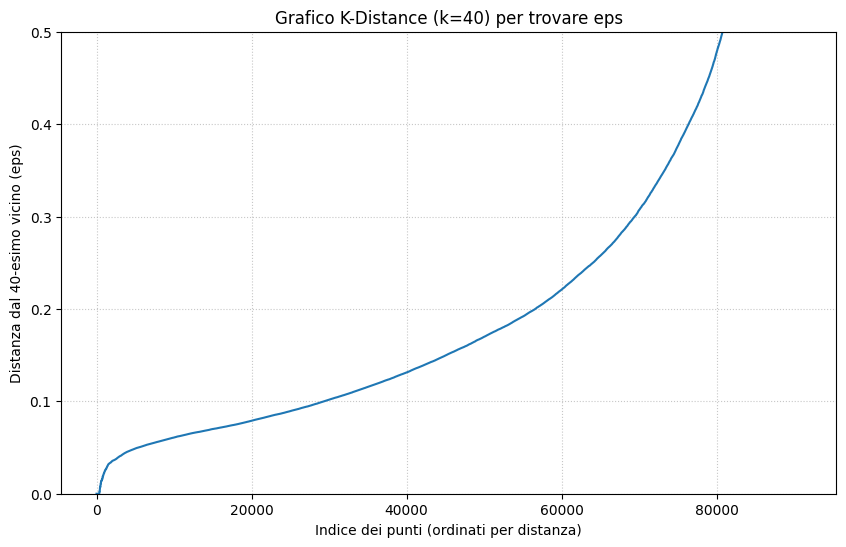

In [5]:
print(f"Dati campionati: {len(X_scaled)} punti")

# Calcolo delle distanze al k-esimo vicino più vicino
k = 40
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

# Plot del grafico
plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.title(f'Grafico K-Distance (k={k}) per trovare eps')
plt.xlabel("Indice dei punti (ordinati per distanza)")
plt.ylabel(f"Distanza dal {k}-esimo vicino (eps)")
plt.grid(True, linestyle=':', alpha=0.7)
plt.ylim(0, 0.5)
plt.show()

### Interpretazione del K-Distance Plot e scelta di *eps*

Il grafico K-Distance rappresenta, per ogni punto del dataset, la distanza dal suo **40-esimo vicino più prossimo**, con i punti ordinati in modo crescente rispetto a tale distanza.

L’andamento della curva può essere suddiviso in tre regioni principali:

1. **Tratto iniziale (pendenza bassa)**  
   Nella prima parte del grafico le distanze crescono lentamente e rimangono molto contenute.  
   Questa zona rappresenta i punti che si trovano in **regioni ad alta densità**, ovvero eventi molto simili tra loro nello spazio delle feature. Questi punti sono i candidati ideali a diventare **core points** in DBSCAN.

2. **Zona di transizione (punto di flesso)**  
   Intorno a valori di distanza compresi approssimativamente tra **0.20 e 0.25** si osserva un cambio evidente nella pendenza della curva.  
   Questo punto di flesso (o “gomito”) separa le regioni dense dal rumore ed è il riferimento principale per la scelta del parametro `eps`.

3. **Tratto finale (pendenza elevata)**  
   Nella parte finale del grafico la distanza cresce rapidamente.  
   Questi punti corrispondono a osservazioni **isolate o poco dense**, che DBSCAN tende a classificare come **rumore (outlier)** se `eps` viene scelto in prossimità del gomito.

Sulla base di questa analisi, un valore di `eps` compreso tra **0.22 e 0.25** risulta una scelta coerente:
- sufficientemente grande da includere le regioni dense;
- sufficientemente piccolo da escludere i punti isolati.

Il valore definitivo di `eps` verrà quindi scelto all’interno di questo intervallo e validato osservando la distribuzione dei cluster e la quantità di rumore prodotta da DBSCAN.


### Clustering degli eventi con DBSCAN (identificazione di hotspot)

Ora si applica l’algoritmo **DBSCAN** allo spazio delle feature standardizzate (`X_scaled`).

A differenza di K-Means, DBSCAN non richiede di fissare a priori il numero di cluster. Invece, individua automaticamente:
- **regioni ad alta densità** (interpretate come *hotspot*),
- e separa i punti **isolati o poco densi**, etichettandoli come **rumore**.

Nel modello vengono impostati:
- `eps = 0.25`, raggio massimo entro cui due punti sono considerati “vicini” nello spazio delle feature;
- `min_samples = 40`, numero minimo di punti necessari per considerare un’area come “densa” (coerente con il valore di `k` usato nel K-distance plot).

DBSCAN restituisce un’etichetta per ogni evento:
- `-1` indica **rumore** (evento non appartenente a nessun hotspot);
- `0, 1, 2, ...` indicano l’appartenenza a uno specifico **cluster/hotspot**.


In [6]:
# Definizione dei parametri DBSCAN
EPSILON = 0.25
MIN_SAMPLES = 40

# Esecuzione di DBSCAN
db = DBSCAN(eps=EPSILON, min_samples=MIN_SAMPLES, metric='euclidean')
cluster_db = db.fit_predict(X_scaled)

# Aggiunta dei risultati di DBSCAN al DataFrame originale
df['cluster'] = cluster_db

print("Punti per cluster (hotspot): (-1 = Rumore/Non-Hotspot)")
print(df['cluster'].value_counts())

# Informazioni riassuntive (molto utili in relazione)
n_clusters = len(set(cluster_db)) - (1 if -1 in cluster_db else 0)
noise_pct = (df['cluster'].eq(-1).mean() * 100)

print(f"\nCluster trovati (escluso rumore): {n_clusters}")
print(f"Percentuale di rumore: {noise_pct:.1f}%")

Punti per cluster (hotspot): (-1 = Rumore/Non-Hotspot)
cluster
-1     19396
 8      8920
 7      8475
 0      6738
 11     5867
       ...  
 79       40
 83       40
 77       40
 73       26
 74       26
Name: count, Length: 86, dtype: int64

Cluster trovati (escluso rumore): 85
Percentuale di rumore: 21.3%


### Interpretazione dei risultati di DBSCAN

L’output mostra la distribuzione dei punti tra i cluster individuati da DBSCAN. In particolare:

- Il valore `-1` rappresenta gli eventi classificati come **rumore** (non appartenenti ad alcuna regione densa).  
  In questo caso il rumore è pari a **19.389 eventi**, che corrisponde a circa **~20%** del dataset: un valore plausibile per DBSCAN su dati reali e ad alta variabilità.

- I cluster con etichetta `0, 7, 8, 11, ...` rappresentano invece gli **hotspot**, cioè gruppi di eventi simili tra loro nello spazio delle feature (posizione + variabili categoriali codificate).  
  Si osservano alcuni cluster molto grandi (ad esempio ~8.9k e ~8.5k eventi), che indicano pattern ripetuti e consistenti nel dataset.

- È presente anche una “coda” di cluster piccoli (es. con ~40 punti o meno). Questo comportamento è normale in DBSCAN: `min_samples` non impone una dimensione minima del cluster, ma stabilisce la densità minima richiesta per identificare almeno un *core point*. Alcuni cluster possono quindi risultare piccoli pur essendo generati da micro-aree localmente dense.

Nel complesso, DBSCAN sta individuando:
1. **pochi hotspot principali** (cluster grandi e stabili),
2. **diversi pattern locali** (cluster piccoli),
3. e una quota di **eventi isolati** (rumore), che verranno esclusi nelle analisi successive sugli hotspot.


### Rimozione del rumore e costruzione del dataset “pulito”

Dopo aver applicato DBSCAN, il dataset risulta suddiviso in:
- **eventi appartenenti a cluster densi** (hotspot),
- **eventi classificati come rumore** (etichetta `-1`).

Poiché l’obiettivo della fase successiva è applicare **K-Means** per individuare strutture globali e confrontabili, è opportuno rimuovere il rumore individuato da DBSCAN.  
In questo modo, K-Means viene applicato **solo ai punti informativi**, evitando che osservazioni isolate o anomale influenzino la posizione dei centroidi.


In [7]:
# Maschera: True per punti NON rumore (cluster DBSCAN diversi da -1)
mask = df['cluster'] != -1

# Dataset pulito (solo punti appartenenti a hotspot)
X_scaled_clean = X_scaled[mask.values]

# Etichette DBSCAN dei punti rimanenti
labels_clean = df.loc[mask, 'cluster'].values

# DataFrame originale filtrato dai punti di rumore
df_clean = df[mask].copy()

print("Dimensioni del dataset pulito:", X_scaled_clean.shape)

# DataFrame numerico standardizzato (input per K-Means)
new_df = pd.DataFrame(
    X_scaled_clean,
    columns=[
        'Latitude', 'Longitude',
        'Description_encoded', 'Weapon_encoded',
        'HourBin_encoded', 'Inside/Outside_encoded'
    ]
)


Dimensioni del dataset pulito: (71479, 6)


### Scelta del numero ottimale di cluster per K-Means

Dopo aver rimosso il rumore tramite DBSCAN, il clustering con **K-Means** viene applicato esclusivamente ai punti appartenenti a regioni dense (hotspot).

Poiché K-Means richiede di specificare a priori il numero di cluster `K`, viene effettuata un’analisi preliminare per individuare il valore più appropriato utilizzando due metriche complementari:

- **Metodo Elbow (Inertia)**: misura la somma delle distanze quadratiche dei punti dal centroide del cluster di appartenenza.  
  Un valore ottimale di `K` è spesso associato a un “gomito” nella curva, oltre il quale la riduzione dell’inerzia diventa marginale.

- **Silhouette Score**: valuta quanto ogni punto è simile al proprio cluster rispetto agli altri.  
  Valori più alti indicano cluster più compatti e meglio separati.

L’analisi viene eseguita su un intervallo di valori di `K` compreso tra 2 e 7, utilizzando come input il dataset pulito ottenuto dopo DBSCAN.


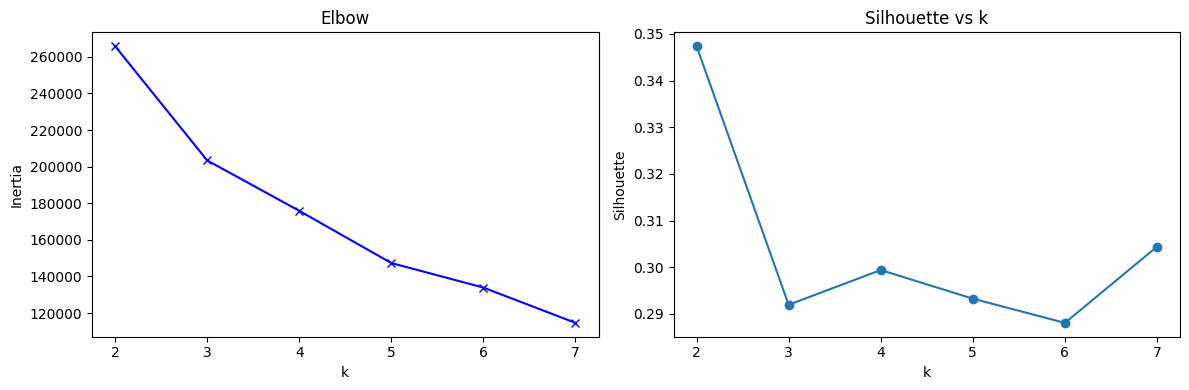

In [8]:
# Elbow Method per determinare il valore ottimale di k
distorsions = []
silhouettes = []
K = range(2, 8)

for k in K:
    km = KMeans(n_clusters=k, n_init='auto', random_state=0)
    labels = km.fit_predict(new_df)
    distorsions.append(km.inertia_)
    silhouettes.append(silhouette_score(new_df, labels))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(K, distorsions, 'bx-')
plt.xlabel('k'); plt.ylabel('Inertia'); plt.title('Elbow')

plt.subplot(1,2,2)
plt.plot(K, silhouettes, 'o-')
plt.xlabel('k'); plt.ylabel('Silhouette'); plt.title('Silhouette vs k')
plt.tight_layout(); plt.show()

### Interpretazione dei grafici Elbow e Silhouette

I grafici ottenuti permettono di valutare il numero ottimale di cluster `K` per l’algoritmo K-Means applicato al dataset filtrato da DBSCAN.

### Analisi dell’Elbow Method

Dal grafico dell’inertia si osserva:
- una forte riduzione dell’inertia passando da \(k = 2\) a \(k = 3\);
- una diminuzione ancora significativa fino a \(k = 5\);
- oltre \(k = 5\), la curva tende a diventare più lineare, indicando benefici marginali sempre più ridotti.

Questo comportamento suggerisce la presenza di un **punto di flesso attorno a \(k = 5\)**, oltre il quale l’aumento del numero di cluster non porta a una reale separazione più significativa dei dati.

### Analisi del Silhouette Score

Il Silhouette Score mostra:
- il valore massimo per \(k = 2\), atteso in quanto una suddivisione binaria tende a produrre cluster artificialmente più separati;
- un valore relativamente elevato e stabile per \(k = 4\);
- oscillazioni e lievi peggioramenti per valori di \(k > 4\).

In particolare, \(k = 4\) rappresenta un buon compromesso tra:
- qualità della separazione dei cluster;
- stabilità del risultato;
- interpretabilità dei gruppi ottenuti.

### Considerazioni finali sulla scelta di \(k\)

Rispetto all’analisi condotta sul dataset non filtrato, il filtraggio tramite DBSCAN:
- riduce l’influenza del rumore e degli outlier;
- rende la struttura dei dati più compatta;
- produce una curva dell’Elbow più regolare e interpretabile.

Alla luce di queste osservazioni, **\(k = 4\)** risulta una scelta coerente e giustificata anche sul dataset filtrato, permettendo un confronto diretto con l’analisi precedente e garantendo cluster stabili e semanticamente interpretabili.


### Esecuzione di K-Means sugli eventi

Dopo aver determinato il valore ottimale di `K` tramite Elbow e Silhouette, si esegue ora il clustering **K-Means con K = 4** sul dataset ripulito dal rumore attraverso DBSCAN (`new_df`).

In questa fase:
- ogni evento viene assegnato a uno dei 4 cluster individuati da K-Means;
- le etichette risultanti vengono aggiunte al dataset originale filtrato (`df_clean`) in una nuova colonna (`event_cluster`).

L’obiettivo è ottenere una partizione globale degli eventi “non rumorosi”, utile per interpretare i profili dei cluster.


In [23]:
# === Fit KMeans e assegnazione agli eventi ===
k_opt1 = 4
kmeans = KMeans(n_clusters=k_opt1, n_init='auto', random_state=0)
labels = kmeans.fit_predict(new_df)

df_kmeans = df_clean.copy()
df_kmeans['event_cluster'] = labels
# Conteggio dei valori per ogni cluster
print(df_kmeans['event_cluster'].value_counts().sort_index())
df_kmeans.head(10)

event_cluster
0    34578
1     6752
2     8738
3    21411
Name: count, dtype: int64


,Description,Inside/Outside,Weapon,Latitude,Longitude,HourBin,Description_encoded,Weapon_encoded,HourBin_encoded,Inside/Outside_encoded,cluster,event_cluster
5,COMMON ASSAULT,Inside,HANDS,39.37070,-76.56709,Night,1,1,3,0,0,0
9,COMMON ASSAULT,Inside,HANDS,39.30340,-76.63842,Morning,1,1,2,0,1,0
11,COMMON ASSAULT,Inside,HANDS,39.30587,-76.67216,Morning,1,1,2,0,1,0
12,COMMON ASSAULT,Inside,HANDS,39.29883,-76.61042,Morning,1,1,2,0,1,0
14,COMMON ASSAULT,Inside,HANDS,39.32120,-76.53906,Morning,1,1,2,0,1,0
19,ROBBERY - STREET,Outside,FIREARM,39.31249,-76.64539,Night,6,0,3,1,2,1
20,ROBBERY - STREET,Outside,FIREARM,39.31249,-76.64539,Night,6,0,3,1,2,1
23,AGG. ASSAULT,Outside,OTHER,39.30038,-76.58101,Night,0,3,3,1,3,2
24,AGG. ASSAULT,Outside,KNIFE,39.30128,-76.58385,Night,0,2,3,1,4,3
27,COMMON ASSAULT,Outside,HANDS,39.34513,-76.54164,Afternoon,1,1,0,1,5,3


### Distribuzione degli eventi nei cluster K-Means

Il risultato mostra il numero di eventi assegnati a ciascun cluster K-Means:

- **Cluster 0**: 34.578 eventi 
- **Cluster 1**: 6.752 eventi  
- **Cluster 2**: 8.738 eventi  
- **Cluster 3**: 21.411 eventi  
 
La distribuzione non è uniforme: alcuni cluster (in particolare il Cluster 0) raccolgono una quota maggiore di eventi, suggerendo la presenza di un pattern più frequente o “generico” nel dataset filtrato.  
Al contrario, cluster più piccoli (Cluster 1 e Cluster 2) potrebbero rappresentare modalità di crimine più specifiche o meno ricorrenti.

Nei passaggi successivi, la composizione dei cluster verrà analizzata e interpretata tramite:
- tecniche di visualizzazione (PCA),
- e confronto delle feature dominanti per ciascun cluster.


### Visualizzazione e interpretazione dei cluster tramite PCA

Per supportare l’interpretazione dei cluster ottenuti con K-Means, viene applicata la **Principal Component Analysis (PCA)** al dataset standardizzato e filtrato (`new_df`).

La PCA consente di:
- ridurre la dimensionalità dei dati,
- proiettare gli eventi in uno spazio a 2 dimensioni,
- analizzare quali variabili contribuiscono maggiormente alla separazione dei cluster.

È importante sottolineare che la PCA **non viene utilizzata per il clustering**, ma esclusivamente come strumento di analisi e interpretazione dei risultati prodotti da K-Means.

In questa analisi viene mostrata la proiezione sulle **prime due componenti principali**, che spiegano la quota maggiore di varianza complessiva.


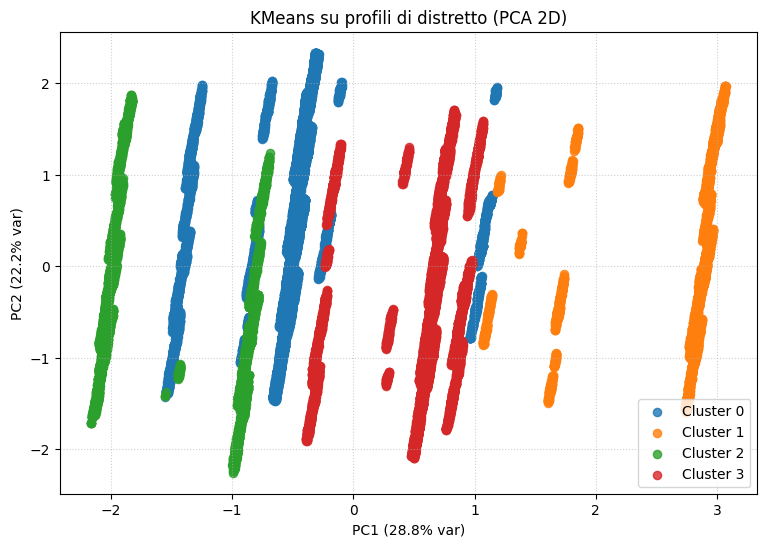

=== PC1 (28.8%) - Cosa sposta i punti a destra/sinistra? ===
--- Spingono a DESTRA (Valori Alti) ---
Description_encoded       0.610927
Inside/Outside_encoded    0.568975
HourBin_encoded           0.062057
Longitude                 0.043803
Latitude                  0.016133
Name: PC1, dtype: float64

--- Spingono a SINISTRA (Valori Bassi) ---
Weapon_encoded           -0.544982
Latitude                  0.016133
Longitude                 0.043803
HourBin_encoded           0.062057
Inside/Outside_encoded    0.568975
Name: PC1, dtype: float64

=== PC2 (22.2%) - Cosa sposta i punti in alto/basso? ===
--- Spingono in ALTO (Valori Alti) ---
HourBin_encoded        0.880935
Longitude              0.323281
Description_encoded    0.057944
Latitude              -0.010016
Weapon_encoded        -0.135328
Name: PC2, dtype: float64

--- Spingono in BASSO (Valori Bassi) ---
Inside/Outside_encoded   -0.312524
Weapon_encoded           -0.135328
Latitude                 -0.010016
Description_encoded    

In [24]:
# === PCA per visualizzare in 2D ===
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(new_df)

plt.figure(figsize=(9,6))
for c in np.unique(labels):
    plt.scatter(
        X_pca[labels == c, 0],
        X_pca[labels == c, 1],
        s=35,
        alpha=0.8,
        label=f'Cluster {c}')

plt.title('KMeans su profili di distretto (PCA 2D)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Crea un DataFrame dei 'loadings' (pesi)
loadings = pd.DataFrame(
    pca.components_.T,  # .T per avere le feature come righe
    columns=['PC1', 'PC2'],
    index=new_df.columns
)

# Stampa le feature più influenti per PC1 (Asse X)
print(f"=== PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%) - Cosa sposta i punti a destra/sinistra? ===")
print("--- Spingono a DESTRA (Valori Alti) ---")
print(loadings['PC1'].sort_values(ascending=False).head(5))
print("\n--- Spingono a SINISTRA (Valori Bassi) ---")
print(loadings['PC1'].sort_values(ascending=True).head(5))

# Stampa le feature più influenti per PC2 (Asse Y)
print(f"\n=== PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%) - Cosa sposta i punti in alto/basso? ===")
print("--- Spingono in ALTO (Valori Alti) ---")
print(loadings['PC2'].sort_values(ascending=False).head(5))
print("\n--- Spingono in BASSO (Valori Bassi) ---")
print(loadings['PC2'].sort_values(ascending=True).head(5))

### Analisi della proiezione PCA in due dimensioni

Il grafico mostra la distribuzione degli eventi nei primi due assi principali (PC1 e PC2), colorati in base al cluster di appartenenza.

Visivamente, i cluster risultano parzialmente sovrapposti e disposti lungo bande quasi verticali. Questo comportamento è coerente con la natura dei dati:
- molte feature sono **categoriche label-encodate**,
- la PCA proietta combinazioni lineari di tali variabili,
- la separazione non è necessariamente “pulita” nello spazio bidimensionale.

Di conseguenza, il valore informativo principale della PCA non risiede tanto nella separazione visiva dei punti, quanto nell’**analisi dei contributi delle variabili alle componenti principali**, riportata di seguito.


### Interpretazione delle componenti principali (PC1 e PC2)

Le componenti principali permettono di comprendere **quali variabili guidano la struttura dei cluster**.

#### PC1 – Asse orizzontale (28.8% della varianza)
La prima componente principale è fortemente influenzata da:
- `Description_encoded` (peso positivo elevato),
- `Inside/Outside_encoded`,
- in misura minore da `HourBin_encoded`.

Valori elevati di PC1 sono quindi associati a:
- specifiche tipologie di reato,
- una forte distinzione tra eventi avvenuti **all’interno o all’esterno**.

Al contrario, valori bassi di PC1 sono principalmente guidati da:
- `Weapon_encoded` (peso negativo rilevante),

suggerendo che questa componente separa gli eventi in base a **modalità del crimine e contesto**, più che alla localizzazione geografica e temporale.

#### PC2 – Asse verticale (22.2% della varianza)
La seconda componente principale è dominata da:
- `HourBin_encoded`, che presenta il contributo più elevato in assoluto.

Questo indica che PC2 rappresenta principalmente una **dimensione temporale**, distinguendo gli eventi in base alla fascia oraria in cui si verificano.

Contributi secondari sono dati da:
- `Longitude` e, in misura minore, `Description_encoded`,
mentre `Inside/Outside_encoded` contribuisce negativamente, spostando i punti verso valori più bassi dell’asse.

Nel complesso:
- **PC1** cattura differenze legate al **tipo di reato e al contesto (interno/esterno)**;
- **PC2** cattura differenze legate prevalentemente al **momento temporale del crimine**.

Questo conferma che i cluster K-Means sono guidati principalmente da **caratteristiche comportamentali e temporali**, più che dalla sola posizione geografica.


### Costruzione dei profili dei cluster

I cluster ottenuti con K-Means sono stati calcolati utilizzando feature numeriche (coordinate + variabili categoriche codificate e standardizzate).  
Tuttavia, per interpretare **il significato reale dei cluster** è necessario tornare a variabili leggibili e confrontabili, come le categorie originali di:

- tipo di reato (`Description`)
- arma (`Weapon`)
- fascia oraria (`HourBin`)
- contesto (`Inside/Outside`)

In questa fase si procede quindi a:

1. eliminare le colonne `_encoded` (utili solo per il clustering numerico);
2. applicare il **One-Hot Encoding** alle colonne categoriche originali;
3. ottenere una rappresentazione binaria (0/1) per ogni categoria, che consente poi di calcolare facilmente **frequenze/percentuali** per cluster.

L’obiettivo è preparare i dati per calcolare, in seguito, la **media per cluster** delle colonne one-hot: tale media corrisponderà alla percentuale di eventi del cluster che appartiene a ciascuna categoria (profilo del cluster).


In [12]:
# Pulizia del dataframe finale con i cluster di Kmeans
# elimino le colonne _encoded e la colonna cluster
cleaned_clustered_values = df_kmeans.drop(columns=['Description_encoded', 'Weapon_encoded', 'HourBin_encoded', 'Inside/Outside_encoded', 'cluster'])

# Categorie per fare il profilo
cat_cols = ['Description','Weapon','HourBin', 'Inside/Outside']

# One-hot encoding (dummies)
dummies = pd.get_dummies(cleaned_clustered_values[cat_cols], drop_first=False)

# Concatenazione dei dummies al dataframe pulito
cleaned_clustered_values = pd.concat([cleaned_clustered_values['event_cluster'].reset_index(drop=True), dummies.reset_index(drop=True)], axis=1)

cleaned_clustered_values.head(10)


,event_cluster,Description_AGG. ASSAULT,Description_COMMON ASSAULT,Description_RAPE,Description_ROBBERY - COMMERCIAL,Description_ROBBERY - RESIDENCE,Description_ROBBERY - STREET,Weapon_FIREARM,Weapon_HANDS,Weapon_KNIFE,Weapon_OTHER,HourBin_Night,HourBin_Morning,HourBin_Afternoon,HourBin_Evening,Inside/Outside_Inside,Inside/Outside_Outside
0,0,False,True,False,False,False,False,False,True,False,False,True,False,False,False,True,False
1,0,False,True,False,False,False,False,False,True,False,False,False,True,False,False,True,False
2,0,False,True,False,False,False,False,False,True,False,False,False,True,False,False,True,False
3,0,False,True,False,False,False,False,False,True,False,False,False,True,False,False,True,False
4,0,False,True,False,False,False,False,False,True,False,False,False,True,False,False,True,False
5,1,False,False,False,False,False,True,True,False,False,False,True,False,False,False,False,True
6,1,False,False,False,False,False,True,True,False,False,False,True,False,False,False,False,True
7,2,True,False,False,False,False,False,False,False,False,True,True,False,False,False,False,True
8,3,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,True
9,3,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True


A questo punto il dataset contiene:
- la colonna `event_cluster`,
- e un insieme di colonne binarie ottenute dal One-Hot Encoding.

Ogni riga rappresenta un evento; le colonne one-hot valgono 1 se l’evento appartiene a quella categoria, altrimenti 0.

Il passo successivo consiste nel **raggruppare per `event_cluster` e calcolare la media** delle colonne one-hot:  
la media di una colonna binaria corrisponde alla **percentuale** di eventi del cluster che appartiene a quella categoria, ottenendo così un **profilo interpretabile del cluster**.


### Creazione dei profili percentuali dei cluster

Dopo aver trasformato le variabili categoriche in colonne binarie tramite **One-Hot Encoding**, è possibile costruire un profilo sintetico per ciascun cluster K-Means.

Il principio è semplice:  
poiché ogni colonna one-hot vale **1** se l’evento appartiene a quella categoria e **0** altrimenti, la **media** di quella colonna all’interno di un cluster corrisponde alla **percentuale di eventi** del cluster che appartiene a quella categoria.

Esempio:
- se in un cluster la colonna `Weapon_HANDS` ha media `0.77`, significa che **il 77% degli eventi** di quel cluster coinvolge “Hands”.

Per ottenere questi profili, si raggruppano i dati per `event_cluster` e si calcola la media delle colonne binarie.


In [25]:
# Aggrego per cluster calcolando i profili percentuali

# Unità di aggregazione: Cluster
profile = cleaned_clustered_values.groupby('event_cluster', as_index=True).mean()

print(profile.round(3))

               Description_AGG. ASSAULT  Description_COMMON ASSAULT  \
event_cluster                                                         
0                                 0.114                       0.863   
1                                 0.000                       0.000   
2                                 0.993                       0.000   
3                                 0.243                       0.757   

               Description_RAPE  Description_ROBBERY - COMMERCIAL  \
event_cluster                                                       
0                         0.000                             0.022   
1                         0.000                             0.000   
2                         0.007                             0.000   
3                         0.000                             0.000   

               Description_ROBBERY - RESIDENCE  Description_ROBBERY - STREET  \
event_cluster                                                                 

### Interpretazione dei profili dei cluster (percentuali)

La tabella risultante descrive, per ciascun cluster, la distribuzione percentuale delle categorie principali (tipo di reato, arma, fascia oraria e contesto Inside/Outside).  
Dall’output emergono profili molto distinti:

### Cluster 0 – Aggressioni e reati comuni all’interno

Il Cluster 0 è caratterizzato prevalentemente da:
- **Common Assault** (circa 86%);
- uso di **mani** come arma principale (circa 89%);
- eventi che avvengono **all’interno** (100%);
- distribuzione temporale abbastanza uniforme, con una leggera prevalenza nel pomeriggio e in serata.

Questo cluster rappresenta un profilo di **reati comuni non armati**, concentrati in contesti chiusi.

### Cluster 1 – Rapine armate in strada

Il Cluster 1 mostra un profilo molto netto:
- quasi esclusivamente **Robbery – Street** (circa 99%);
- forte presenza di **armi da fuoco** (circa 87%);
- eventi che avvengono quasi sempre **all’esterno**;
- maggiore concentrazione in **orario serale e notturno**.

Si tratta quindi di un cluster che identifica chiaramente **rapine armate in strada**, con una dinamica temporale e spaziale ben definita.

### Cluster 2 – Aggressioni con armi non convenzionali

Il Cluster 2 è fortemente dominato da:
- **Agg. Assault** (circa 99%);
- utilizzo esclusivo di **armi classificate come “Other”** (100%);
- distribuzione equilibrata tra **interno ed esterno**;
- maggiore frequenza nel **pomeriggio e in serata**.

Questo cluster descrive un insieme di **aggressioni gravi** che non rientrano nelle categorie classiche di arma, suggerendo dinamiche particolari.

### Cluster 3 – Aggressioni comuni all’esterno

Il Cluster 3 è caratterizzato da:
- prevalenza di **Common Assault** (circa 76%);
- utilizzo prevalente di **mani** e **coltelli**;
- eventi che avvengono esclusivamente **all’esterno**;
- distribuzione temporale simile al Cluster 0, con maggiore presenza nel pomeriggio e in serata.

Questo cluster rappresenta **aggressioni comuni in contesti aperti**, distinguendosi dal Cluster 0 principalmente per il contesto spaziale.

### Considerazioni generali

L’analisi dei profili percentuali evidenzia come, dopo il filtraggio del rumore tramite DBSCAN, i cluster risultino:
- più **compatti**;
- meglio **caratterizzati da specifiche tipologie di reato**;
- più facilmente interpretabili dal punto di vista semantico.

Tuttavia, questa rappresentazione tende a enfatizzare le caratteristiche più frequenti, motivo per cui, nel seguito, viene introdotta l’analisi tramite **lift**, utile a mettere in evidenza anche fenomeni meno ricorrenti ma distintivi.


### Analisi descrittiva dei cluster tramite heatmap dei profili percentuali

La heatmap consente di:
- confrontare visivamente i cluster tra loro,
- individuare rapidamente le feature **più frequenti** all’interno di ciascun gruppo,
- ottenere una prima intuizione sulle differenze strutturali tra i cluster.

È importante sottolineare che questa analisi riflette **le frequenze assolute** delle variabili, senza tenere conto della loro rarità o diffusione nel dataset complessivo.


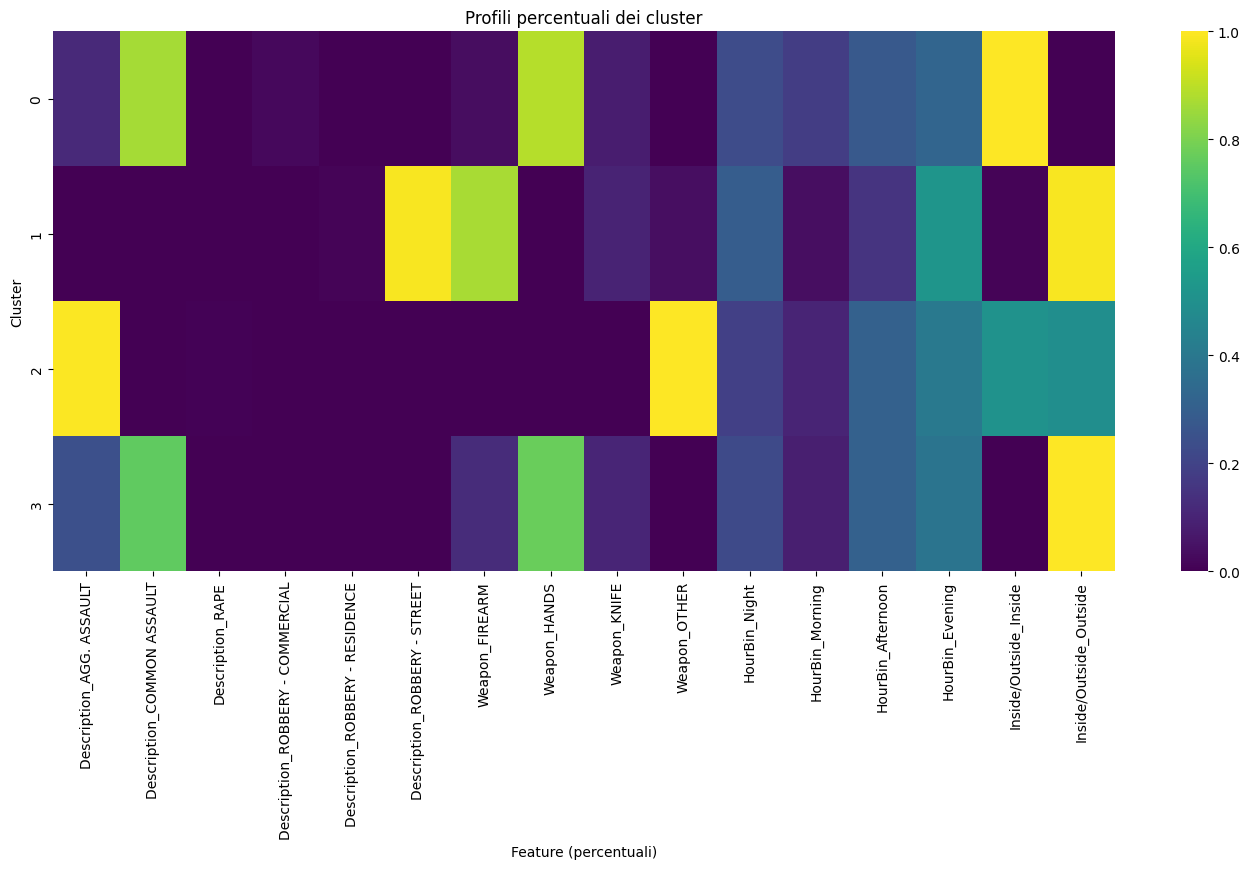

In [26]:
# === Heatmap dei centroidi per confronto rapido ===
plt.figure(figsize=(min(16, 0.5*len(profile.columns)+6), 1.2*k_opt1+4))
sns.heatmap(
    profile,
    cmap='viridis',
    annot=False,
    cbar=True
)
plt.title('Profili percentuali dei cluster')
plt.xlabel('Feature (percentuali)')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

### Interpretazione della heatmap e limiti dell’analisi percentuale

Dalla heatmap emergono pattern chiari e coerenti con quanto osservato nei passaggi precedenti:

- alcuni cluster risultano dominati da specifiche tipologie di reato (ad esempio aggressioni comuni o rapine),
- la distribuzione delle armi e del contesto Inside/Outside evidenzia differenze marcate tra i cluster,
- le fasce orarie mostrano una certa variabilità, ma con trend abbastanza regolari.

Tuttavia, questa rappresentazione mette in evidenza **soprattutto le categorie più frequenti in assoluto** nel dataset.  
Di conseguenza:
- variabili rare (come `RAPE`, `ROBBERY - COMMERCIAL` o alcune tipologie di arma) appaiono poco rilevanti,
- non è possibile distinguere se una feature sia realmente *caratteristica* di un cluster o semplicemente comune ovunque.

In altre parole, la heatmap risponde alla domanda:
> *“Cosa accade più spesso all’interno di ciascun cluster?”*

ma non consente di rispondere a:
> *“Cosa rende questo cluster diverso dagli altri?”*

Per superare questo limite e ottenere una caratterizzazione più significativa dei cluster, viene introdotta l’analisi del **Lift**, che confronta la probabilità di ciascuna feature nel cluster rispetto alla media globale del dataset.


### Analisi del Lift: individuazione delle caratteristiche distintive dei cluster

L’analisi basata sulle percentuali (medie delle colonne one-hot) permette di comprendere quali categorie sono più frequenti all’interno di ciascun cluster. Tuttavia, questo approccio presenta un limite importante:  
le categorie molto comuni a livello globale tendono a dominare la rappresentazione, mentre eventi meno frequenti ma altamente caratterizzanti rischiano di essere sottovalutati.

Per superare questo limite, viene introdotta l’**analisi del Lift**.

Il Lift confronta, per ogni feature e per ogni cluster, la sua incidenza nel cluster rispetto alla **media globale dell’intero dataset**. In questo modo è possibile identificare non solo ciò che è frequente, ma soprattutto ciò che è **sovra-rappresentato** in un cluster rispetto al comportamento medio complessivo.

Formalmente:
- **Lift > 1** indica che una feature è più presente nel cluster rispetto alla media globale;
- **Lift = 1** indica una presenza in linea con la media;
- **Lift < 1** indica una sotto-rappresentazione.

Questa analisi consente di assegnare una “firma” chiara a ciascun cluster, evidenziandone le peculiarità reali.


In [27]:
# === LIFT rispetto alla media globale ===
global_mean = profile.mean()

lift = profile.copy()
for col in lift.columns:
    baseline = global_mean[col] if global_mean[col] != 0 else 1e-9
    lift[col] = lift[col] / baseline  # >1 = sopra la media globale

for c in lift.index:
    print(f'\n=== {c}: feature con lift più alto ===')
    print(
        lift.loc[c]
        .sort_values(ascending=False)
        .head(15)
        .round(2))


=== 0: feature con lift più alto ===
Description_ROBBERY - COMMERCIAL    4.00
Inside/Outside_Inside               2.64
Weapon_HANDS                        2.14
Description_COMMON ASSAULT          2.13
HourBin_Morning                     1.78
Weapon_KNIFE                        1.14
HourBin_Afternoon                   1.06
HourBin_Night                       0.97
HourBin_Evening                     0.78
Description_AGG. ASSAULT            0.34
Weapon_FIREARM                      0.13
Description_RAPE                    0.00
Description_ROBBERY - RESIDENCE     0.00
Description_ROBBERY - STREET        0.00
Weapon_OTHER                        0.00
Name: 0, dtype: float64

=== 1: feature con lift più alto ===
Description_ROBBERY - RESIDENCE     4.00
Description_ROBBERY - STREET        4.00
Weapon_FIREARM                      3.39
Inside/Outside_Outside              1.60
Weapon_KNIFE                        1.38
HourBin_Evening                     1.28
HourBin_Night                       1.2

### Interpretazione dettagliata dei risultati del Lift

L’analisi del Lift consente di individuare, per ciascun cluster, le caratteristiche **realmente distintive** rispetto alla media complessiva del dataset.  
Valori di Lift significativamente maggiori di 1 indicano feature che risultano sovra-rappresentate nel cluster, anche quando la loro frequenza assoluta è bassa.

Di seguito vengono analizzati i profili emersi.

---

### Cluster 0

Il Cluster 0 è fortemente caratterizzato da:
- **Robbery – Commercial** (lift = 4.00), che risulta nettamente sovra-rappresentata;
- eventi **all’interno** (Inside = 2.64);
- **Common Assault** (2.13) e utilizzo delle **mani** come arma (2.14);
- maggiore incidenza nelle fasce **mattutine** e **pomeridiane**.

Questo cluster descrive quindi episodi prevalentemente interni, non armati o con armi improprie, spesso legati a contesti commerciali.

### Cluster 1

Il Cluster 1 mostra un profilo molto netto e specifico:
- **Robbery – Residence** e **Robbery – Street** risultano entrambe fortemente sovra-rappresentate (lift = 4.00);
- utilizzo marcato di **armi da fuoco** (3.39);
- prevalenza di eventi **all’esterno** (1.60);
- concentrazione nelle fasce **serali e notturne**.

Questo cluster rappresenta chiaramente episodi di rapina ad alta pericolosità, spesso armati e svolti in contesti aperti.

### Cluster 2

Il Cluster 2 è dominato da:
- **Rape** (lift = 4.00), evento estremamente distintivo del cluster;
- uso di **Weapon\_Other** (3.86);
- presenza significativa di **Agg. Assault** (2.94);
- maggiore incidenza **all’interno**;
- eventi concentrati soprattutto nel **pomeriggio**.

Si tratta di un cluster molto specifico, che raccoglie eventi rari ma altamente caratterizzanti, emersi chiaramente grazie al filtraggio preliminare tramite DBSCAN.

### Cluster 3

Il Cluster 3 è caratterizzato da:
- **Common Assault** (1.87);
- utilizzo delle **mani** (1.86) e, in misura minore, di **coltelli** (1.48);
- prevalenza di eventi **all’esterno** (1.61);
- maggiore concentrazione nel **pomeriggio** e in parte durante la notte.

Questo cluster descrive episodi di aggressione comuni, meno gravi rispetto ai cluster di rapina armata, ma distinti per contesto e modalità.

### Considerazioni finali sul Lift

L’analisi del lift conferma che il filtraggio tramite DBSCAN:
- migliora la **separazione semantica** dei cluster;
- rende più evidenti eventi rari ma rilevanti;
- consente di assegnare una **“personalità” chiara** a ciascun cluster.

Rispetto alla sola analisi percentuale, il lift fornisce una lettura più profonda e discriminante, risultando fondamentale per interpretare correttamente la struttura dei dati dopo il clustering.
